# Introduction to Model Evaluation in Supervised Learning

Evaluating machine learning models is a critical step in the supervised learning workflow. It allows us to understand how well our trained model is likely to perform on new, unseen data. Without proper evaluation, we risk deploying models that may not generalize well, leading to poor predictions and potentially detrimental outcomes in real-world applications.

Think of training a model like a student studying for an exam. The training data is like the practice questions. If the student only memorizes the answers to the practice questions without understanding the underlying concepts (overfitting), they might perform poorly on the actual exam which contains different questions. Model evaluation is like giving the student a separate set of practice questions they haven't seen before to truly test their understanding and ability to generalize.

Proper evaluation helps us:
*   Assess the model's performance on independent data.
*   Compare different models and select the best one for the task.
*   Identify issues like overfitting (model performs well on training data but poorly on unseen data) or underfitting (model performs poorly on both training and unseen data).
*   Gain confidence in the model's ability to make reliable predictions in a production environment.

This notebook will guide you through essential model evaluation techniques for supervised learning, covering:

*   **Classification Metrics:** Metrics like Accuracy, Precision, Recall, F1-score, and AUC, used for evaluating models that predict categorical outcomes.
*   **Regression Metrics:** Metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE) and $R^2$, used for evaluating models that predict continuous numerical values.
*   **Cross-Validation:** A powerful technique to obtain a more reliable estimate of model performance by splitting the data into multiple folds for training and testing.

## References and Further Reading

*   [Scikit-learn Documentation on Model Evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html)

## Classification Metrics

When evaluating supervised learning models for classification tasks, where the goal is to predict a categorical label, we use specific metrics to assess performance. Unlike regression, where we measure the difference between predicted and actual continuous values, classification evaluation focuses on how well the model assigns instances to the correct categories.

A simple measure like just counting the number of correct predictions can be misleading, especially when dealing with imbalanced datasets (where one class is much more frequent than others). Therefore, we use a suite of metrics that provide a more nuanced understanding of the model's performance.

This section will cover the following key classification metrics:

*   **Accuracy:** The overall proportion of correct predictions.
*   **Precision:** The proportion of positive predictions that were actually correct.
*   **Recall (Sensitivity):** The proportion of actual positive instances that were correctly identified.
*   **F1-score:** The harmonic mean of Precision and Recall, providing a single metric that balances both.
*   **Confusion Matrix:** A table that summarizes the performance of a classification model by showing the counts of true positive, true negative, false positive, and false negative predictions.
* **AUC (Area under the ROC curve):** Shows how well a model separates classes by looking at its performance across all decision thresholds.

### Accuracy

Accuracy is the most intuitive performance measure and it is simply a ratio of correctly predicted observation to the total observations. It is a good measure when the target variable classes are nearly balanced. However, when the classes are imbalanced, it can be a misleading metric.

The formula for Accuracy is:

$$ \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} $$

This can also be expressed in terms of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN):

$$ \text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}} $$

Where:
*   **True Positives (TP):** The number of instances correctly predicted as positive.
*   **True Negatives (TN):** The number of instances correctly predicted as negative.
*   **False Positives (FP):** The number of instances incorrectly predicted as positive (Type I error).
*   **False Negatives (FN):** The number of instances incorrectly predicted as negative (Type II error).

Using `make_classification` from `sklearn.datasets` lets us generate a synthetic dataset on the fly

In [1]:
import pandas as pd
import numpy as np
import math

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_classification(
    n_samples=1000,
    n_features=2,        # only 2 features for easy plotting
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    n_classes=2,
    random_state=42,
    class_sep=0.5,
    weights=[0.85, 0.15] # imbalanced dataset
)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# Train a Logistic Regression model
model = SVC(C=1.0, kernel='rbf')
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9000


/tmp/ipython-input-3319550809.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == i, 0], X[y == i, 1], marker=marker, edgecolor='k', s=60, label=class_labels[i])


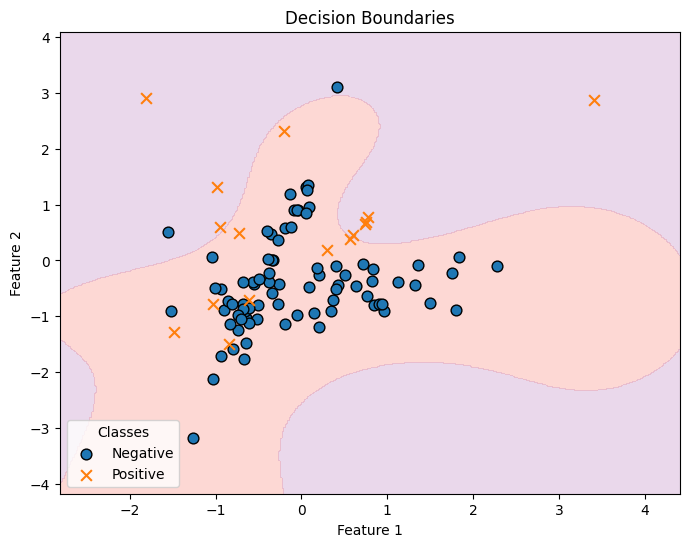

In [2]:
import matplotlib.pyplot as plt

def plot_decision_boundaries(X, y, model, class_labels=None):
  n_classes = len(np.unique(y))

  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                      np.arange(y_min, y_max, 0.02))

  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  plt.figure(figsize=(8,6))
  plt.contourf(xx, yy, Z, alpha=0.3,
                 levels=np.arange(n_classes+1)-0.5,  # center boundaries between class labels
                 cmap=plt.cm.Set3)
  markers = ['o', 'x', '*', 's', 'D']

  if class_labels is None:
    class_labels = [f"Class {i}" for i in range(n_classes)]

  # Plot points
  for i, marker in zip(range(n_classes), markers * ((n_classes // len(markers)) + 1)):
      plt.scatter(X[y == i, 0], X[y == i, 1], marker=marker, edgecolor='k', s=60, label=class_labels[i])

  plt.legend(title="Classes")
  plt.title("Decision Boundaries")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.show()
plot_decision_boundaries(X_test, y_test, model, class_labels=["Negative", "Positive"])

In binary classification, accuracy alone can be misleading—especially for imbalanced datasets, like in this example where 85% of samples belong to class 0 and only 15% to class 1. A model could predict the majority class most of the time and still achieve high accuracy, but fail to detect the minority class.

### Confusion Matrix

The Confusion Matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm, showing counts of true positives, true negatives, false positives, and false negatives.

For a binary classification problem, the confusion matrix looks like this:

|                  | Predicted Positive | Predicted Negative |
|------------------|--------------------|--------------------|
| **Actual Positive** | True Positive (TP) | False Negative (FN)|
| **Actual Negative** | False Positive (FP)| True Negative (TN) |

In a multi-class setting, the confusion matrix expands to an N x N matrix, where N is the number of classes. Each row represents the instances in an actual class, and each column represents the instances in a predicted class. The diagonal elements represent the number of instances that were correctly classified for each class.

Let's break down the terms:

*   **True Positives (TP):** The number of instances that were actually positive and were correctly predicted as positive.
*   **True Negatives (TN):** The number of instances that were actually negative and were correctly predicted as negative.
*   **False Positives (FP):** The number of instances that were actually negative but were incorrectly predicted as positive (Type I error). This is also known as a "false alarm".
*   **False Negatives (FN):** The number of instances that were actually positive but were incorrectly predicted as negative (Type II error). This is also known as a "miss".

The Confusion Matrix provides a detailed breakdown of correct and incorrect predictions for each class, which is invaluable for understanding where the model is making errors.

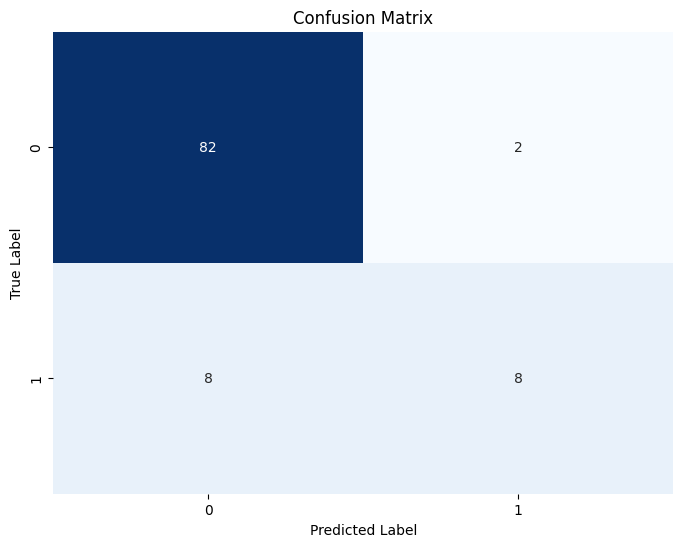

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the Confusion Matrix


def plot_cm(y_test, y_pred):
  conf_matrix = confusion_matrix(y_test, y_pred)
  # Visualize the Confusion Matrix using a heatmap
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()

plot_cm(y_test, y_pred)

### Precision and Recall

Precision and recall are metrics used to evaluate the performance of classification models, especially when dealing with imbalanced datasets.

* Precision measures how many of the predicted positive instances are actually positive. A high precision means the model makes few false positive errors.
* Recall (also called sensitivity) measures how many of the actual positive instances were correctly identified. A high recall means the model captures most of the real positives, with few false negatives.

![precision vs recall](https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/800px-Precisionrecall.svg.png)

### Precision

Precision is the ratio of correctly predicted positive observations to the total predicted positive observations. It answers the question: "Of all the instances the model predicted as positive, how many were actually positive?". High precision relates to a low False Positive rate.

$$ \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} $$

Precision is particularly relevant when the cost of a **false positive** is high. For example, in spam detection, a high-precision model would minimize the chance of marking a legitimate email as spam.


In [4]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

Precision: 0.8000


### Recall (Sensitivity or True Positive Rate)

Recall is the ratio of correctly predicted positive observations to all observations in the actual class. It answers the question: "Of all the actual positive instances, how many did the model correctly identify?". High recall relates to a low **False Negative** rate.


$$ \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} $$

Recall is particularly relevant when the cost of a false negative is high. For example, in medical diagnosis, a high-recall model would minimize the chance of missing a disease (a false negative).


In [5]:
from sklearn.metrics import recall_score

# Calculate and print the recall score
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.5000


### F1-score

The F1-score is the harmonic mean of Precision and Recall. It is a way of combining Precision and Recall into a single measure that captures both properties.

$$ \text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

<details>
  <summary>What is the reason for using the harmonic mean rather than the arithmetic mean?</summary>
  
  The harmonic mean is used instead of a simple arithmetic mean because it **penalizes extreme values**. A high F1-score means that the model has both high precision and high recall.

  The F1-score is a good metric when you need to balance Precision and Recall, especially in cases with uneven class distribution.
</details>



In [6]:
from sklearn.metrics import f1_score

# Calculate and print the F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

F1-score: 0.6154


When evaluating binary classification models, it’s important to identify which metric (precision, recall, or F1-score) is most relevant for the use case. Different applications prioritize different types of errors: sometimes false positives are costly, other times false negatives are critical.

Let’s see a few examples:

Spam email classifier
<details>
  <summary>Precision, Recall or F1?</summary>
  
  **Precision**	- Users get annoyed if legitimate emails are marked as spam (false positives). It’s better to miss some spam than flag important emails.
</details>


Airport Security Scan (e.g., detecting weapons)
<details>
  <summary>Precision, Recall or F1?</summary>
  
  **Recall** - Missing a threat (false negative) is very costly. It’s better to have some false alarms than to let a weapon through.
</details>

Cancer Detection (e.g., breast cancer screening)
<details>
  <summary>Precision, Recall or F1?</summary>
  
  **Recall** -	Missing a cancer case can be life-threatening. High recall ensures most patients with cancer are flagged for further testing, though some false positives are acceptable.
</details>



Credit Card Fraud Detection
<details>
  <summary>Precision, Recall or F1?</summary>
  
  **F1** -	Missing a fraudulent transaction (false negative) can be costly. Precision is also important to avoid blocking legitimate transactions, so F1 is often used as a balance.
</details>



Churn Prediction
<details>
  <summary>Precision, Recall or F1?</summary>
  
  **F1** -	Identifying potential churners is important for retention campaigns (recall), but precision matters too for marketing efficiency. F1-score is usually chosen to balance both.
</details>



Intrusion Detection in Networks
<details>
  <summary>Precision, Recall or F1?</summary>
  
  **F1**	- Missing an attack (false negative) is dangerous; false positives can be handled. Balance often measured with F1.
</details>



### F-beta Score

The F-beta score is a generalization of the F1-score that allows you to put more emphasis on either Precision or Recall.

$$ F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}} $$

The $\beta$ parameter determines the weight of Recall in the score:

* **$\beta = 1$:** This is the standard F1-score, where Precision and Recall are equally weighted.
* **$\beta < 1$:**  More emphasis is placed on **Precision**.  This is useful when false positives are more costly than false negatives (e.g., spam detection).
* **$\beta > 1$:** More emphasis is placed on **Recall**. This is useful when false negatives are more costly than false positives (e.g., medical diagnosis).

For example, an F2-score ($\beta=2$) weighs Recall twice as much as Precision. An F0.5-score ($\beta=0.5$) weighs Precision twice as much as Recall.

In [7]:
from sklearn.metrics import fbeta_score

print(f"Precision: {precision}, Recall: {recall}")
# Calculate F-beta score with beta = 0.5 (more emphasis on Precision)
fbeta_05 = fbeta_score(y_test, y_pred, beta=0.5)
print(f"F-beta score (beta=0.5): {fbeta_05:.4f}")

fbeta_1 = fbeta_score(y_test, y_pred, beta=1)
print(f"F-beta score (beta=1): {fbeta_1:.4f}")
assert fbeta_1 == f1_score(y_test, y_pred)

# Calculate F-beta score with beta = 2 (more emphasis on Recall)
fbeta_2 = fbeta_score(y_test, y_pred, beta=2)
print(f"F-beta score (beta=2): {fbeta_2:.4f}")

Precision: 0.8, Recall: 0.5
F-beta score (beta=0.5): 0.7143
F-beta score (beta=1): 0.6154
F-beta score (beta=2): 0.5405


### AUC

The Receiver Operating Characteristic (ROC) curve is a tool that evaluates the trade-off between sensitivity (recall) and specificity across different decision thresholds.

True Positive Rate (TPR / Recall / Sensitivity) = fraction of actual positives correctly identified.
$$ \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} $$

True Negative Rate (TNR / Specificity) = fraction of actual negatives correctly identified.

$$ \text{Specificity} = \frac{\text{True Negatives}}{\text{True Negatives} + \text{False Positives}} $$


False Positive Rate (FPR) = fraction of negatives incorrectly labeled as positive.

$$ \text{FPR} = 1 - \text{Specificity} = \frac{\text{False Positives}}{\text{False Positives} + \text{True Negatives}} $$

The ROC curve plots TPR vs. FPR at various thresholds.

The Area Under the ROC Curve (**AUC**) summarizes the model’s ability to distinguish between the two classes:

* AUC = 1.0 → perfect classifier
* AUC = 0.5 → random guessing

ROC curves are particularly useful for imbalanced datasets, as they focus on the model’s ability to separate classes rather than being dominated by the majority class.

AUC: 0.8943


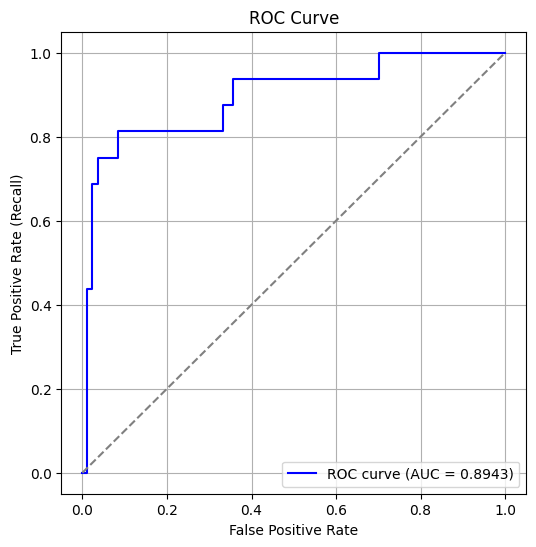

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

model_prob = SVC(C=1.0, kernel='rbf', probability=True)
model_prob.fit(X_train, y_train)

# Get predicted probabilities for the positive class
y_scores = model_prob.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC
auc = roc_auc_score(y_test, y_scores)
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line = random
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Multiclass examples

In this example, we generate a synthetic 4-class dataset with two features using `make_classification`. The classes are imbalanced to simulate a more realistic scenario where some classes appear more frequently than others.

We train a Support Vector Classifier (SVC) with an RBF kernel and evaluate it on a test set.

Since this is a multi-class problem, metrics like precision and recall can be computed in different ways:

* Macro average: Compute precision/recall per class and take the unweighted mean. All classes are treated equally, regardless of size.
* Weighted average: Compute precision/recall per class and take the mean weighted by class support. This accounts for class imbalance.
* Micro average: Aggregate the contributions of all classes to compute global precision/recall.

/tmp/ipython-input-3319550809.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == i, 0], X[y == i, 1], marker=marker, edgecolor='k', s=60, label=class_labels[i])


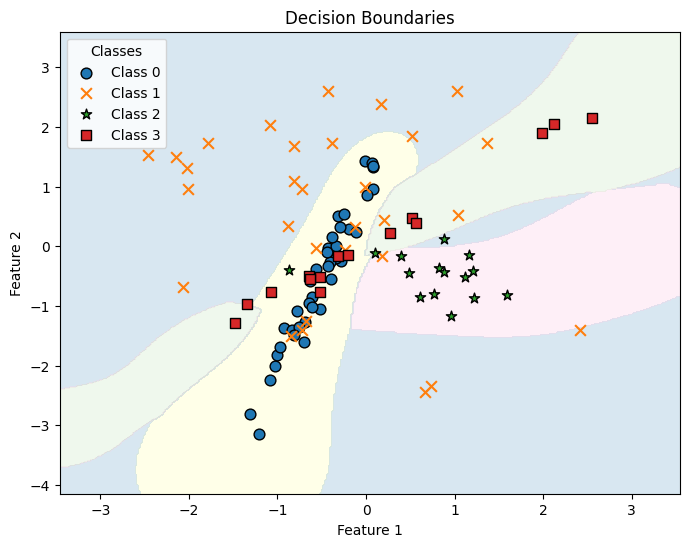

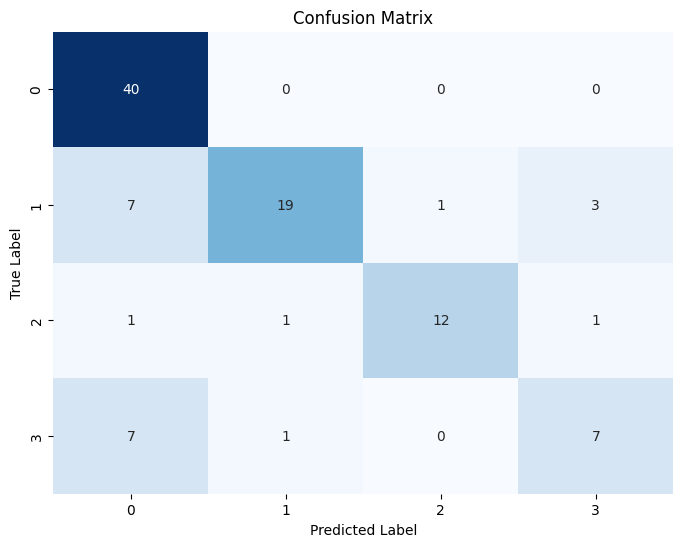

In [9]:
weights=[0.4, 0.3, 0.15, 0.15] # imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=2,        # only 2 features for easy plotting
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=4,
    random_state=42,
    class_sep=0.5,
    weights=weights
)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

model = SVC(C=1.0, kernel='rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plot_decision_boundaries(X_test, y_test, model)
plot_cm(y_test, y_pred)

In [10]:
prec_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

print("Precision per class:", prec_per_class)
print("Recall per class:", recall_per_class)
print("F1 per class:", f1_per_class)

Precision per class: [0.72727273 0.9047619  0.92307692 0.63636364]
Recall per class: [1.         0.63333333 0.8        0.46666667]
F1 per class: [0.84210526 0.74509804 0.85714286 0.53846154]


In [11]:
# Macro is the mean
precision = precision_score(y_test, y_pred, average='macro')
print(f"Precision (macro): {precision:.4f}")
assert precision == np.mean(prec_per_class)

recall = recall_score(y_test, y_pred, average='macro')
print(f"Recall (macro): {recall:.4f}")
assert recall == np.mean(recall_per_class)

f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1-score (macro): {f1:.4f}")
assert f1 == np.mean(f1_per_class)

Precision (macro): 0.7979
Recall (macro): 0.7250
F1-score (macro): 0.7457


In [12]:
# weighted is the weighted mean
precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision (weighted): {precision:.4f}")
assert math.isclose(precision, np.average(prec_per_class, weights=weights))

recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall (weighted): {recall:.4f}")
assert math.isclose(recall, np.average(recall_per_class, weights=weights))

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-score (weighted): {f1:.4f}")
assert math.isclose(f1, np.average(f1_per_class, weights=weights))

Precision (weighted): 0.7963
Recall (weighted): 0.7800
F1-score (weighted): 0.7697


In [13]:
# micro calculates metrics by counting total true positives, false positives, and false negatives globally across all classes.
# Essentially, it’s like flattening all classes into a single binary problem.

cm = confusion_matrix(y_test, y_pred)

# True positives (sum of diagonal)
TP = cm.diagonal().sum()
# False positives: sum of each column minus diagonal
FP = cm.sum(axis=0) - cm.diagonal()
# False negatives: sum of each row minus diagonal
FN = cm.sum(axis=1) - cm.diagonal()

print(f"True positives: {TP}")
print(f"False positives: {FP}, Sum: {FP.sum()}")
print(f"False negatives: {FN}, Sum: {FN.sum()}")

precision_micro = precision_score(y_test, y_pred, average='micro')
print(f"Precision (micro): {precision_micro:.4f}")
precision_manual = TP / (TP + FP.sum())
assert math.isclose(precision_micro, precision_manual)


recall_micro = recall_score(y_test, y_pred, average='micro')
print(f"Recall (micro):    {recall_micro:.4f}")
recall_manual = TP / (TP + FN.sum())
assert math.isclose(recall_micro, recall_manual)

f1_micro = f1_score(y_test, y_pred, average='micro')
print(f"F1-score (micro):  {f1_micro:.4f}")
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)
assert math.isclose(f1_micro, f1_manual)

True positives: 78
False positives: [15  2  1  4], Sum: 22
False negatives: [ 0 11  3  8], Sum: 22
Precision (micro): 0.7800
Recall (micro):    0.7800
F1-score (micro):  0.7800


## Regression Metrics

In contrast to classification tasks where we predict discrete categories, regression tasks involve predicting continuous numerical values. Evaluating regression models requires different metrics that quantify the difference between the predicted values and the actual target values. These metrics help us understand how close our model's predictions are to the true values and provide a measure of the model's error.

For regression problems, lower values of these error metrics generally indicate better model performance.

This section will focus on two common and important regression evaluation metrics:

*   **Mean Absolute Error (MAE):** Measures the average magnitude of the errors, without considering their direction.
*   **Mean Squared Error (MSE):** Measures the average of the squares of the errors. It gives more weight to larger errors.
* **$R^2$ (R-squared):** Measures how well a regression model’s predictions explain the variance of the true values, with 1 meaning perfect prediction and 0 meaning no better than predicting the mean.

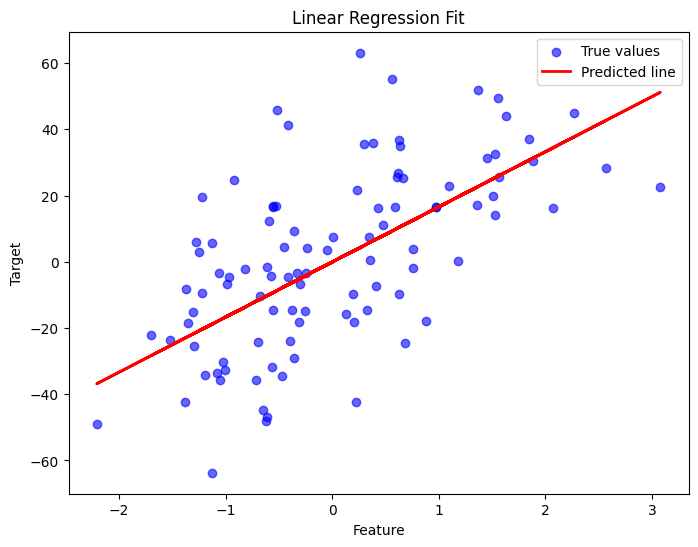

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=1000,
    n_features=1,   # 1D feature for easy plotting
    noise=20,       # noise to make it more realistic
    random_state=42
)


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='True values')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted line')
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

### Mean Absolute Error (MAE)

Mean Absolute Error (MAE) is a simple and intuitive metric that measures the average magnitude of the errors between predicted and actual values. It calculates the average of the absolute differences between predictions and the actual values.

The MAE is less sensitive to outliers compared to the Mean Squared Error because it uses the absolute value of the errors, not their square. This makes it a good choice when the presence of outliers is a concern and you want an error metric that is not heavily influenced by them. The units of MAE are the same as the units of the target variable, which can make it easier to interpret.

The formula for Mean Absolute Error is:

$$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

Where:
*   $n$ is the number of data points.
*   $y_i$ is the actual value for the $i$-th data point.
*   $\hat{y}_i$ is the predicted value for the $i$-th data point.
*   $|y_i - \hat{y}_i|$ is the absolute difference between the actual and predicted values.

In [15]:
from sklearn.metrics import mean_absolute_error

# Calculate and print the Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Mean Absolute Error (MAE): 17.0559


### Mean Squared Error (MSE)

Mean Squared Error (MSE) is another common regression metric. It measures the average of the squares of the errors between predicted and actual values.

Compared to MAE, MSE gives more weight to larger errors because the errors are squared. This means that MSE is more sensitive to outliers. If large errors are particularly undesirable in your application, MSE might be a more appropriate metric.

The formula for Mean Squared Error is:

$$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Where:
*   $n$ is the number of data points.
*   $y_i$ is the actual value for the $i$-th data point.
*   $\hat{y}_i$ is the predicted value for the $i$-th data point.
*   $(y_i - \hat{y}_i)^2$ is the squared difference between the actual and predicted values.

In [16]:
from sklearn.metrics import mean_squared_error

# Calculate and print the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

Mean Squared Error (MSE): 458.3677


### Root Mean Squared Error (RMSE)

A related metric is the **Root Mean Squared Error (RMSE)**, which is simply the square root of the MSE:

$$ \text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$


RMSE has the same units as the target variable, which can make it easier to interpret than MSE. Both MSE and RMSE are widely used, and the choice between them often depends on whether you want to emphasize larger errors (MSE/RMSE) or treat all errors equally in terms of magnitude (MAE).

In [17]:
from sklearn.metrics import root_mean_squared_error

# Calculate and print the Root Mean Squared Error (RMSE)
mse = root_mean_squared_error(y_test, y_pred)
print(f"Root mean Squared Error (RMSE): {mse:.4f}")

Root mean Squared Error (RMSE): 21.4095


### $R^2$ (Coefficient of Determination)

[$R^2$](https://www.youtube.com/watch?v=-7U10N8PvlQ), also known as the coefficient of determination, is another important metric for evaluating regression models. Unlike MAE and MSE, which measure the error in absolute terms, $R^2$ provides a measure of how well the model's predictions fit the actual data points. It represents the proportion of the variance in the dependent variable that is predictable from the independent variables.


$$ R^2 = 1 - \frac{\text{Sum of Squared Residuals (SSR)}}{\text{Total Sum of Squares (SST)}} = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} $$

Where:
* $y_i$ is the actual value.
* $\hat{y}_i$ is the predicted value.
* $\bar{y}$ is the mean of the actual values.
* SSR (Sum of Squared Residuals) is the sum of the squared differences between the actual and predicted values.
* SST (Total Sum of Squares) is the sum of the squared differences between the actual values and their mean.

$R^2$ values range from 0 to 1:

* **$R^2 = 1$:** The model perfectly predicts the variance in the target variable.
* **$R^2 = 0$:** The model does not explain any of the variance in the target variable. The predictions are no better than simply predicting the mean of the target variable.
* **$R^2 < 0$:** This can happen if the model is significantly worse than simply predicting the mean. This is uncommon for a well-trained model.

$R^2$ is a useful metric for understanding the overall goodness of fit of a regression model. However, it's important to note that a high $R^2$ doesn't necessarily mean the model is good or that the relationship is causal. It simply indicates how much of the variance in the dependent variable is explained by the model.

In [18]:
from sklearn.metrics import r2_score

# Calculate and print the R^2 score
r2 = r2_score(y_test, y_pred)
print(f"R^2 score: {r2:.4f}")

R^2 score: 0.3649


## K-Fold Cross-Validation

So far, we've evaluated our models using a single train-test split. While simple, this method has a drawback: the performance estimate can be highly dependent on the specific data points that ended up in the test set. If the split results in a test set that is not representative of the overall data distribution, our evaluation might be overly optimistic or pessimistic.

**Cross-validation** is a more robust technique for estimating model performance. It allows us to use our data more effectively for both training and evaluation, providing a more reliable measure of how the model is likely to perform on unseen data.

### How K-Fold Cross-Validation Works

K-Fold Cross-Validation is a widely used type of cross-validation. Here's how it works:

1.  **Divide the data into k folds:** The entire dataset is randomly partitioned into $k$ equally sized subsamples or "folds".
2.  **Iterate k times:** The cross-validation process is repeated $k$ times.
3.  **Training and Testing:** In each iteration:
    *   One fold is reserved as the **test set** (or validation set).
    *   The remaining $k-1$ folds are used as the **training set**.
4.  **Evaluate:** The model is trained on the training set and evaluated on the test set. The performance metric (e.g., accuracy, MSE) is recorded for this fold.
5.  **Repeat:** This process is repeated $k$ times, with each of the $k$ folds used exactly once as the test set.

After $k$ iterations, we will have $k$ performance scores (one for each fold).

### Benefits of K-Fold Cross-Validation

*   **More Robust Performance Estimate:** By averaging the performance across $k$ different train-test splits, we get a less biased and more reliable estimate of the model's true performance on unseen data. It reduces the dependence on a single, potentially unrepresentative, test set.
*   **Better Use of Data:** Every data point gets to be in the test set exactly once and in the training set $k-1$ times. This ensures that all data is used for both training and evaluation, which is particularly beneficial when working with smaller datasets.
*   **Helps Detect Overfitting:** If the model performs significantly better on the training folds compared to the test folds across multiple splits, it can be an indication of overfitting.

The value of $k$ is typically chosen to be 5 or 10, but it can vary depending on the size of the dataset. A larger $k$ leads to a more robust estimate but also increases the computational cost.

![5-fold CV](https://towardsdatascience.com/wp-content/uploads/2023/12/1N45hocCMP0u4nXLe0WuSvw.png)

In [19]:
import numpy as np
from sklearn.model_selection import cross_val_score, cross_val_predict

X, y = make_regression(
    n_samples=1000,
    n_features=5,   # 1D feature for easy plotting
    noise=20,       # noise to make it more realistic
    random_state=42
)


# Re-initialize the Logistic Regression model (untrained)
model_cv = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Perform 5-fold cross-validation using r2 as the scoring metric on the full dataset
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

# Calculate the mean and standard deviation of the cross-validation scores
mean_cv_score = np.mean(cv_scores)
std_cv_score = np.std(cv_scores)

# Print the mean and standard deviation
print(f"Mean Cross-validation score: {mean_cv_score:.4f}")
print(f"Standard Deviation of Cross-validation score: {std_cv_score:.4f}")

# Print the accuracy scores for each fold
print("Cross-validation scores for each fold:", cv_scores)

Mean Cross-validation score: 0.9058
Standard Deviation of Cross-validation score: 0.0084
Cross-validation scores for each fold: [0.90225386 0.90727217 0.91916835 0.89338013 0.90698667]


R² on test set: 0.894195002713362


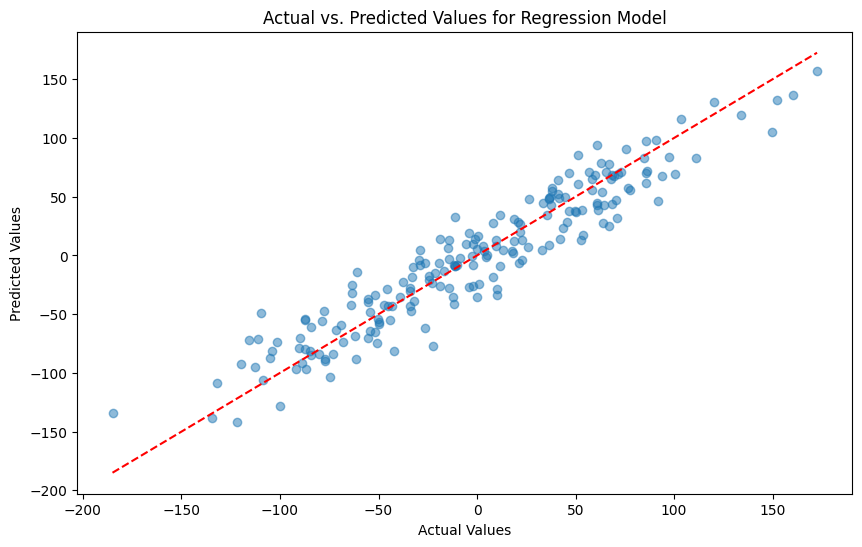

In [20]:
import matplotlib.pyplot as plt
import numpy as np

final_model = LinearRegression().fit(X_train, y_train)

y_pred = final_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
print("R² on test set:", test_r2)

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Add a diagonal line
# Determine the range for the diagonal line based on the data
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

# Label the axes and add a title
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Regression Model')

# Display the plot
plt.show()

## Grid Search

Choosing the right hyperparameters for a machine learning model is crucial for achieving optimal performance. Hyperparameters are parameters that are not learned from the data but are set before the training process begins (e.g., the regularization parameter `C` in SVM, the learning rate in a neural network, the number of neighbors in k-NN). The performance of a model can be highly sensitive to the choice of hyperparameters.

**Grid Search** is a common technique for hyperparameter tuning. It works by systematically searching through a predefined set of hyperparameter values (a "grid") and evaluating the model's performance for each combination of hyperparameters. The combination that yields the best performance on a validation set or through cross-validation is then selected as the optimal set of hyperparameters.

### How Grid Search Works

1. **Define the Hyperparameter Grid:** Specify a range of values for each hyperparameter you want to tune. For example, for an SVM with an RBF kernel, you might define a grid for the `C` parameter and the `gamma` parameter.
2. **Iterate through the Grid:** Grid Search explores every possible combination of hyperparameter values in the defined grid.
3. **Train and Evaluate for Each Combination:** For each combination of hyperparameters, the model is trained (typically using cross-validation on the training data) and evaluated using a chosen performance metric (e.g., accuracy for classification, MSE for regression).
4. **Select the Best Hyperparameters:** The hyperparameter combination that results in the best performance score is chosen as the optimal set.
5. **Train Final Model:** The final model is trained on the entire training dataset using the selected optimal hyperparameters.

Grid Search can be computationally expensive, especially when the hyperparameter grid is large or the model training is time-consuming. However, it is a straightforward and effective method for finding good hyperparameters.

Libraries like scikit-learn provide convenient implementations of Grid Search (e.g., `GridSearchCV`) that integrate with cross-validation.

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Define the parameter grid for SVR
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.1, 1], # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly']       # Kernel type
}

# Initialize the SVR model
svr = SVR()

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2)

# Fit the grid search to the training data
# Assuming X_train, y_train are already defined from a previous split
# If not, you would need to split your data first
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print(f"Best parameters found by Grid Search: {grid_search.best_params_}")
print(f"Best cross-validation score (negative MSE): {grid_search.best_score_}")

# You can access the best model directly
best_svr_model = grid_search.best_estimator_


Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale


Mean Squared Error on test set with best parameters: 444.0699


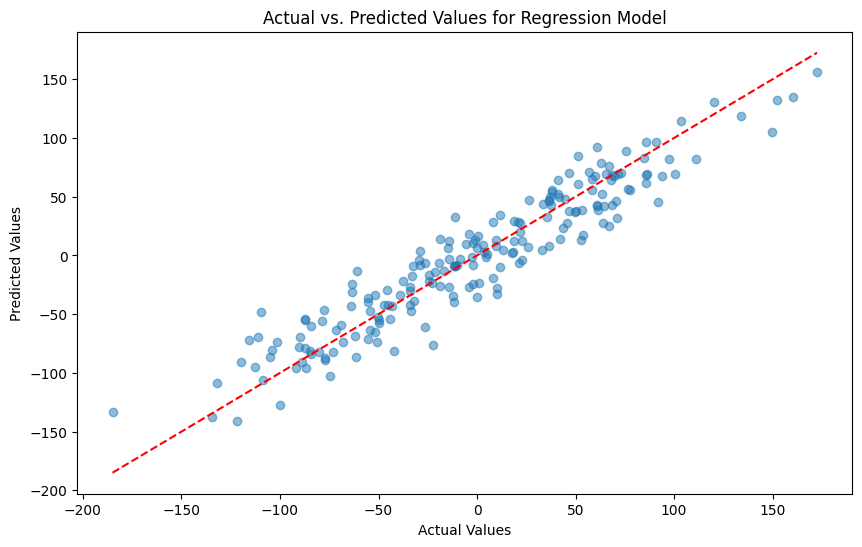

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set using the trained model
y_pred = best_svr_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
print(f"\nMean Squared Error on test set with best parameters: {test_mse:.4f}")

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Add a diagonal line representing perfect predictions
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Regression Model')
plt.show()

### Randomized Search Cross-Validation

While Grid Search is a systematic approach to hyperparameter tuning, it can become computationally expensive as the number of hyperparameters and their possible values increase. **Randomized Search Cross-Validation** offers an alternative that can be more efficient, especially when the hyperparameter space is large.

Instead of trying every single combination like Grid Search, Randomized Search samples a fixed number of hyperparameter combinations from the specified distributions or lists. This allows you to explore a wider range of values for each hyperparameter without the need to evaluate every single combination.

### How Randomized Search Works

1. **Define the Hyperparameter Space:** Specify a range or distribution of values for each hyperparameter you want to tune. This can be a list of discrete values (like in Grid Search) or a statistical distribution (e.g., a uniform or exponential distribution).
2. **Specify the Number of Iterations:** Define the number of different hyperparameter combinations you want to sample and evaluate. This is the `n_iter` parameter in scikit-learn's `RandomizedSearchCV`.
3. **Sample and Evaluate:** Randomized Search randomly samples `n_iter` combinations of hyperparameters from the defined space. For each sampled combination, the model is trained (typically using cross-validation) and evaluated using a chosen performance metric.
4. **Select the Best Hyperparameters:** The hyperparameter combination that results in the best performance score among the sampled combinations is chosen.
5. **Train Final Model:** The final model is trained on the entire training dataset using the selected best hyperparameters.

Randomized Search can be more efficient than Grid Search because it does not evaluate every combination. It's particularly useful when you suspect that only a few hyperparameters significantly impact performance, or when you want to quickly get a good set of hyperparameters without exhaustively searching the entire space. The quality of the results depends on the number of iterations and the chosen distributions for the hyperparameters.

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END C=374.54011884736246, gamma=0.3010121430917521, kernel=poly; total time=   0.9s
[CV] END C=374.54011884736246, gamma=0.3010121430917521, kernel=poly; total time=   1.1s
[CV] END C=374.54011884736246, gamma=0.3010121430917521, kernel=poly; total time=   1.3s
[CV] END C=374.54011884736246, gamma=0.3010121430917521, kernel=poly; total time=   1.2s
[CV] END C=374.54011884736246, gamma=0.3010121430917521, kernel=poly; total time=   1.3s
[CV] END C=779.6910002727693, gamma=0.09084469696321254, kernel=linear; total time=   0.6s
[CV] END C=779.6910002727693, gamma=0.09084469696321254, kernel=linear; total time=   0.9s
[CV] END C=779.6910002727693, gamma=0.09084469696321254, kernel=linear; total time=   0.5s
[CV] END C=779.6910002727693, gamma=0.09084469696321254, kernel=linear; total time=   0.4s
[CV] END C=779.6910002727693, gamma=0.09084469696321254, kernel=linear; total time=   0.4s
[CV] END C=155.99452033620264, gamma=0

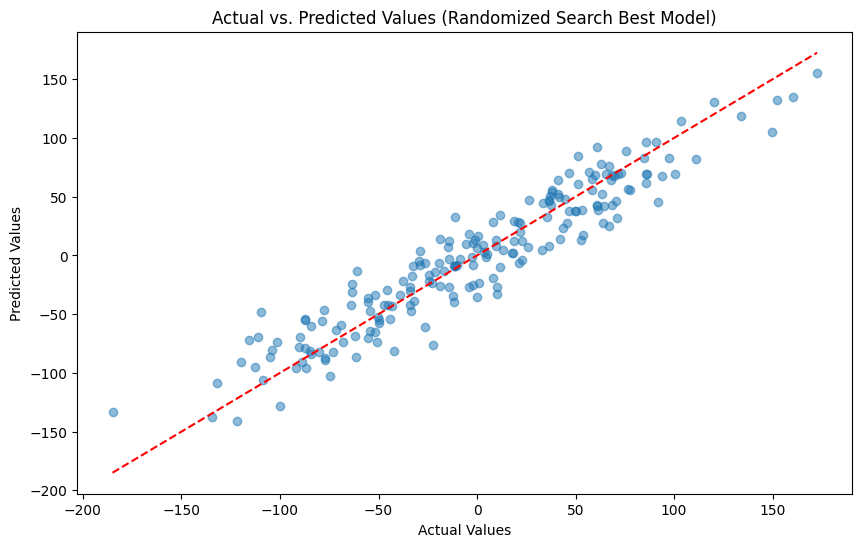

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from scipy.stats import uniform, expon
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Define the parameter distribution for SVR
# Using distributions for a more "randomized" search
param_dist = {
    'C': uniform(loc=0, scale=1000),  # Uniform distribution between 0 and 1000
    'gamma': expon(scale=.1),        # Exponential distribution with scale 0.1
    'kernel': ['rbf', 'linear', 'poly'] # Discrete values for kernel
}

# Initialize the SVR model
svr = SVR()

# Initialize RandomizedSearchCV with 5-fold cross-validation and specify the number of iterations
n_iter_search = 50  # Increase iterations to sample more of the distribution
random_search = RandomizedSearchCV(svr, param_dist, n_iter=n_iter_search, cv=5, scoring='neg_mean_squared_error', random_state=42, verbose=2)

# Fit the random search to the training data
# Assuming X_train, y_train are already defined
random_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters found by Randomized Search:")
print(random_search.best_params_)
print("\nBest cross-validation score (negative MSE):")
print(random_search.best_score_)

# You can access the best model directly
best_svr_model_random = random_search.best_estimator_

# Evaluate the best model on the test set (if you have one)
y_pred_best_random = best_svr_model_random.predict(X_test)
test_mse_random = mean_squared_error(y_test, y_pred_best_random)
print(f"\nMean Squared Error on test set with best parameters from Randomized Search: {test_mse_random:.4f}")

# Create a scatter plot for the best randomized search model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best_random, alpha=0.5)

# Add a diagonal line representing perfect predictions
min_val = min(min(y_test), min(y_pred_best_random))
max_val = max(max(y_test), max(y_pred_best_random))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values (Randomized Search Best Model)')
plt.show()

## Assignment: Applying Model Evaluation Techniques


**Objective:** Apply the model evaluation concepts learned in this notebook to a new dataset and task. You will practice data loading, model training, evaluating performance using appropriate metrics, and utilizing cross-validation.

**Dataset:** [Mushroom Classification](https://www.kaggle.com/datasets/uciml/mushroom-classification)



**Task:**

1.  **Data Exploration:**
    *   Perform basic exploratory data analysis (EDA) to understand the data structure, identify missing values, and visualize key features (e.g., distributions, relationships).
2.  **Data Preprocessing:**
    *   Handle missing values (e.g., imputation, dropping rows/columns).
    *   Encode categorical features if necessary
    *   Split the data into training and testing sets.
3.  **Model Selection and Training:**
    *   Choose at least one appropriate model (e.g., Logistic Regression, SVM, Decision Tree).
    *   Train the selected model(s) on the training data.
4.  **Model Evaluation (Initial):**
    *   Evaluate the trained model(s) on the test set using the appropriate metrics covered in this notebook: Accuracy, Precision, Recall, F1-score, Confusion Matrix (visualize the confusion matrix), AUC.
    *   Discuss the initial performance based on these metrics.
5.  **Cross-Validation:**
    *   Implement K-Fold Cross-Validation (e.g., with k=5 or 10) on your chosen model and the full dataset.
    *   Calculate and report the mean and standard deviation of the cross-validation scores.
    *   Compare the performance estimate from cross-validation to the initial evaluation on the single test split.
6.  **Interpretation and Conclusion:**
    *   Summarize your findings. What do the evaluation metrics tell you about your model's performance?
    *   Discuss any challenges encountered and potential next steps (e.g., feature engineering, trying different models, hyperparameter tuning).

**Deliverables:**

*   A Jupyter Notebook containing all the code used for data loading, preprocessing, model training, and evaluation. Ensure your code is well-commented.
*   Include markdown cells explaining your steps, observations, and interpretations of the results and evaluation metrics.
*   Include visualizations where appropriate (e.g., confusion matrix heatmap, scatter plot of actual vs. predicted values for regression).
*   A brief written summary (can be within the notebook) outlining your key findings, the performance of your model(s), and reflections on the evaluation process.


In [24]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")

df = pd.read_csv(os.path.join(path, 'mushrooms.csv'))
df.describe()

100%|██████████| 34.2k/34.2k [00:00<00:00, 30.5MB/s]

Extracting files...


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148
